Importando Biblioteca

In [67]:
# Bibliotecas essenciais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import sys
import subprocess

from pathlib import Path
import os
import gc

# Para Deep Learning
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
									MaxPooling2D,
                                    GlobalAveragePooling2D,
									Flatten,
									Dense,
									Dropout,
									Conv2D,
									BatchNormalization,
                                    Activation  
								)

from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint)
from tensorflow.keras.optimizers import Adam

from tensorflow.keras.utils import to_categorical

# Para o ViT
from transformers import TFViTModel

# Para validação do modelo
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn import model_selection
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV, train_test_split

import pickle

In [68]:
print("="*50)
print("VERSÕES DO AMBIENTE")
print("="*50)

print(f"Python: {sys.version}")
print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")
print(f"NumPy: {np.__version__}")
print(f"OpenCV: {cv2.__version__}")


print("\n" + "="*50)
print("GPU / CUDA")
print("="*50)

print("GPUs encontradas pelo TensorFlow:")

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    for gpu in gpus:
        print(gpu)
else:
    print("Nenhuma GPU encontrada")


print("\nBuild CUDA/cuDNN do TensorFlow:")

build_info = tf.sysconfig.get_build_info()

print(f"CUDA utilizada pelo TensorFlow: {build_info.get('cuda_version')}")
print(f"cuDNN utilizado pelo TensorFlow: {build_info.get('cudnn_version')}")


print("\n" + "="*50)
print("NVIDIA DRIVER / GPU")
print("="*50)

try:
    resultado = subprocess.check_output(
        [
            "nvidia-smi",
            "--query-gpu=name,driver_version,memory.total",
            "--format=csv,noheader"
        ],
        encoding="utf-8"
    )

    print(resultado)

except Exception as e:
    print("Não foi possível consultar nvidia-smi")
    print(e)

VERSÕES DO AMBIENTE
Python: 3.10.10 (tags/v3.10.10:aad5f6a, Feb  7 2023, 17:20:36) [MSC v.1929 64 bit (AMD64)]
TensorFlow: 2.10.1
Keras: 2.10.0
NumPy: 1.23.5
OpenCV: 4.8.1

GPU / CUDA
GPUs encontradas pelo TensorFlow:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

Build CUDA/cuDNN do TensorFlow:
CUDA utilizada pelo TensorFlow: 64_112
cuDNN utilizado pelo TensorFlow: 64_8

NVIDIA DRIVER / GPU
NVIDIA GeForce RTX 3060, 610.74, 12288 MiB



In [69]:
def unpickle(file):
    
    with open(file, 'rb') as fo:
        data = pickle.load(
            fo,
            encoding='bytes'
        )

    return data

In [70]:
base_dir = "./cifar-10-python"

base_files = [
    "data_batch_1",
    "data_batch_2",
    "data_batch_3",
    "data_batch_4",
    "data_batch_5"
]


X_base = []
y_base = []


for file in base_files:

    caminho = os.path.join(
        base_dir,
        file
    )

    batch = unpickle(caminho)

    X_base.append(
        batch[b'data']
    )

    y_base.extend(
        batch[b'labels']
    )

In [71]:
batch[b'data'].shape

(10000, 3072)

In [72]:
meta_path = os.path.join(base_dir, "batches.meta")

meta = unpickle(meta_path)

category_names = [
    nome.decode('utf-8')
    for nome in meta[b'label_names']
]

category_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

Treinando Dados

In [73]:
X_base = np.concatenate(
    X_base,
    axis=0
)

y_base = np.array(y_base)

In [74]:
X_base.shape

(50000, 3072)

In [75]:
y_base.shape

(50000,)

In [76]:
X_base = X_base.reshape(
    -1,
    3,
    32,
    32
)

In [77]:
X_base.shape

(50000, 3, 32, 32)

In [78]:
X_base = np.transpose(
    X_base,
    (0,2,3,1)
)

In [79]:
X_base.shape

(50000, 32, 32, 3)

In [80]:
X_base = X_base.astype('float32') / 255.0

In [81]:
X_base.shape

(50000, 32, 32, 3)

In [82]:
y_base.shape

(50000,)

Construindo um dataframe

In [83]:
num_classes = len(np.unique(y_base))

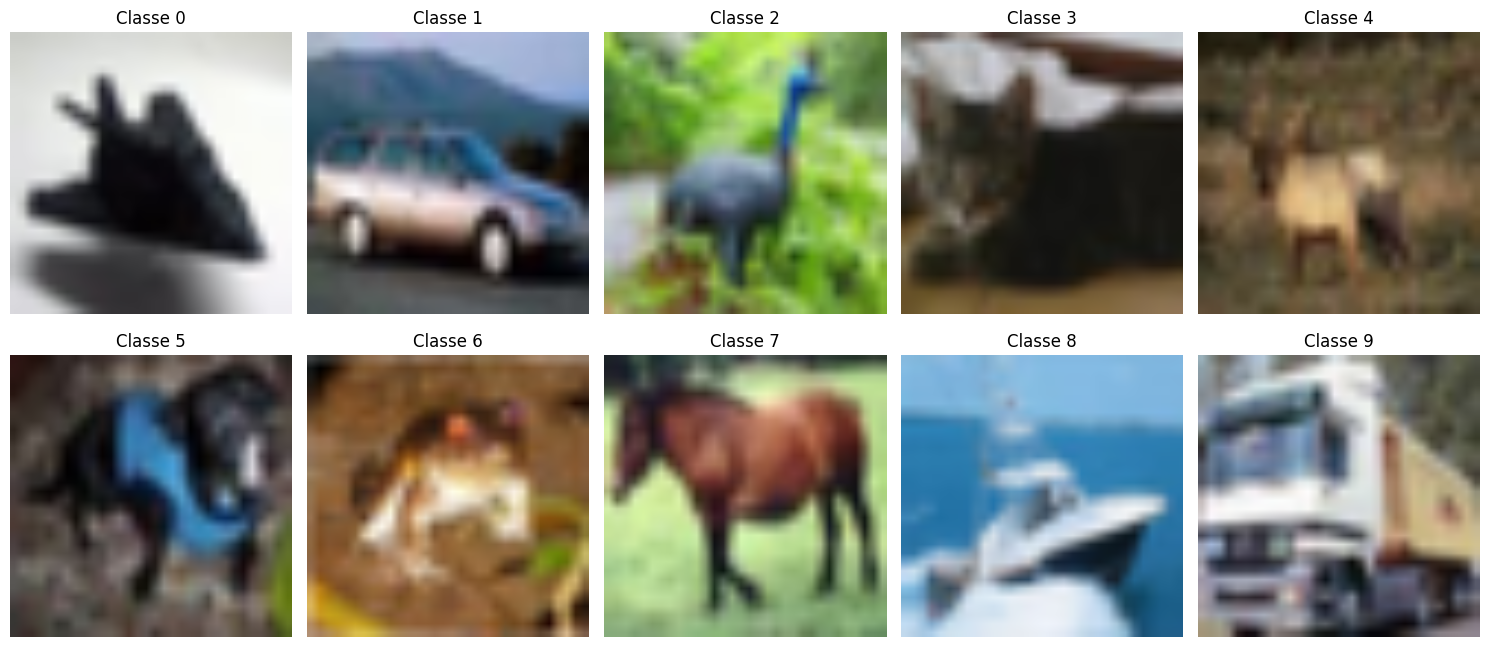

In [84]:
# Configura o número de linhas e colunas para visualizar os dados no plot
ROW = 2
COLUMN = 5

# Dimensões da figura
plt.figure(figsize=(15, 7))

# Loop para cada classe
for i in range(num_classes):
    # Obtém o caminho da imagem
    image = X_base[np.where(y_base == i)[0][0]]

    # Define a posição da imagem no grid
    plt.subplot(ROW, COLUMN, i + 1)

    # Carrega e mostra a imagem
    plt.imshow(image, interpolation='bilinear')

    # Adiciona o nome da classe
    plt.title(f'Classe {i}')

    # Remove os eixos
    plt.axis('off')

    # Ajusta espaçamento
    plt.tight_layout()

plt.show()

In [85]:
# Tamanho das imagens no CIFAR10
image_size = 32

# Define a forma de entrada das imagens passadas pelo modelo
input_shape = (image_size, image_size, 3)

# Defina a taxa de aprendizado e a queda de peso para o otimizador usar
learning_rate = 0.001

# Defindo uma semente aleatória para utilizar sempre os mesmos dados durante nossos testes
rand_seed = 42
tf.random.set_seed(rand_seed) 

# Define o numero de epocas de treinamento global
training_epochs = 50


## Separando em treino e teste a base de dados

Agora com as imagens e classes organizadas, podemos aplicar o train_test_split para separar as bases de treinamento e teste:

In [86]:
X_base.shape

(50000, 32, 32, 3)

In [87]:
x_train, x_test, y_train, y_test = train_test_split(X_base,y_base, test_size=0.3, stratify=y_base, random_state=rand_seed)


In [88]:
# Analisando a dimensão dos dados
x_train.shape

(35000, 32, 32, 3)

In [89]:
x_test.shape

(15000, 32, 32, 3)

In [90]:
# # Achatar os dados de teste e treinamento
# x_train_flat = x_train.reshape(x_train.shape[0], x_train.shape[1]* x_train.shape[2]* x_train.shape[3])
# x_test_flat = x_test.reshape(x_test.shape[0], x_test.shape[1] * x_test.shape[2] * x_test.shape[3])

In [91]:
# # Visualizando a transformação
# x_train_flat.shape

In [92]:
# Converte um vetor de classe (inteiros) em uma matriz de classe categórica.
y_train_tf = keras.utils.to_categorical(y_train, num_classes)
y_test_tf = keras.utils.to_categorical(y_test, num_classes)

 Vamos configurar agora como próximo passo o ModelCheckpoint para usar os melhores pesos para este modelo. Um dos benefícios do ModelCheckpoint é salvar uma cópia do modelo em disco em intervalos regulares (como após cada época de processamento) para que você possa retomar o treinamento a partir do ponto em que parou, minimizando perdas de tempo e recursos computacionais.

In [93]:
# Defina um objeto ModelCheckpoint para usar os melhores pesos para este modelo
checkpointer = ModelCheckpoint(filepath="cnn_weights.best.keras", verbose=0, save_best_only=True) # save best model

Treinando a CNN

In [ ]:
model = Sequential() # Abrindo a sequencia do modelo

model.add(Input(shape=input_shape)) # primeira camada explicita

# 1 camada convolucional com 128 neurônios | filtro utilizando uma matriz 3x3 sendo movimentado por um stride de 2
# padding ativado (com bordas de zeros) | função de ativação ReLU | regularização L2 ativada
model.add(Conv2D(128,
                 kernel_size=(3, 3),
                 strides=(1, 1),
                 padding='same',
                 kernel_regularizer=keras.regularizers.l2(0.001),
                 use_bias=False
                 )
        )

model.add(BatchNormalization())
model.add(Activation('relu'))

# 2 camada convolucional com 92 neurônios | filtro utilizando uma matriz 3x3 sendo movimentado por um stride de 2
# padding ativado (com bordas de zeros) | função de ativação ReLU | regularização L2 ativada
model.add(Conv2D(92,
                 kernel_size=(3, 3),
                 strides=(1, 1),
                 padding='same',
                 kernel_regularizer=keras.regularizers.l2(0.001),
                 use_bias=False
                 )
        )

model.add(BatchNormalization())
model.add(Activation('relu'))

# Camada de MaxPolling ativada, com uma matriz 2x2. Padding ativado
model.add(MaxPooling2D(pool_size=(2, 2), strides=None, padding='same'))

# Regularização de dropout ativada
model.add(Dropout(0.2))

# Camada que achata dos dados da imagem
model.add(Flatten())
# Camada Densa da rede neural convolucional + função de ativação ReLU
model.add(Dense(256, activation='relu'))
# Camada de saída da rede, utilizando a função de ativação softmax
model.add(Dense(10, activation='softmax'))

In [95]:
# Monitor para interromper o modelo antecipadamente quando a melhoria da perda de validação for mínima
monitor = EarlyStopping(monitor='val_loss', min_delta=1e-5, patience=10, verbose=1, mode='auto')

# Compilando o modelo e aplicação a função de custo Adam (utilizando a learning rate que configuramos anteriormente)
model.compile(loss="categorical_crossentropy", optimizer=Adam(learning_rate), metrics=['accuracy'])

# Salve os dados do modelo em um arquivo keras
model.save('./modeloAtividade1.keras')
# Resumo do modelo
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 128)       3456      
                                                                 
 batch_normalization (BatchN  (None, 32, 32, 128)      512       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 32, 32, 128)       0         
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 92)        105984    
                                                                 
 batch_normalization_1 (Batc  (None, 32, 32, 92)       368       
 hNormalization)                                                 
                                                                 
 activation_1 (Activation)   (None, 32, 32, 92)        0

In [96]:
# Treinando o modelo
history = model.fit(x_train,y_train_tf, validation_split=0.25, callbacks=[monitor,checkpointer],
                    verbose=1, epochs=training_epochs, batch_size=32, shuffle=True)

# Carrega os melhores pesos pra usar na cnn

model.load_weights("cnn_weights.best.keras")

Epoch 1/50
821/821 [==============================] - 13s 14ms/step - loss: 2.1287 - accuracy: 0.3974 - val_loss: 1.8074 - val_accuracy: 0.4121
Epoch 2/50
821/821 [==============================] - 11s 13ms/step - loss: 1.3846 - accuracy: 0.5247 - val_loss: 1.6711 - val_accuracy: 0.4547
Epoch 3/50
821/821 [==============================] - 11s 13ms/step - loss: 1.2023 - accuracy: 0.5923 - val_loss: 1.3478 - val_accuracy: 0.5486
Epoch 4/50
821/821 [==============================] - 11s 13ms/step - loss: 1.0895 - accuracy: 0.6376 - val_loss: 1.3153 - val_accuracy: 0.5592
Epoch 5/50
821/821 [==============================] - 11s 13ms/step - loss: 1.0143 - accuracy: 0.6657 - val_loss: 1.1243 - val_accuracy: 0.6321
Epoch 6/50
821/821 [==============================] - 11s 14ms/step - loss: 0.9603 - accuracy: 0.6872 - val_loss: 1.1700 - val_accuracy: 0.6171
Epoch 7/50
821/821 [==============================] - 10s 13ms/step - loss: 0.8991 - accuracy: 0.7097 - val_loss: 1.3102 - val_accuracy:

Validação do Modelo

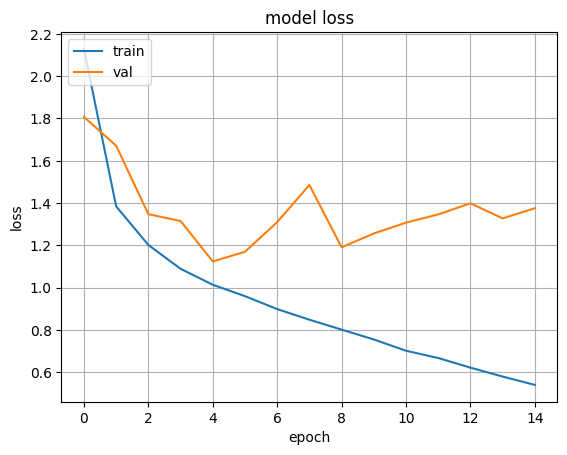

In [97]:
# Validação o erro por épocas
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.show()

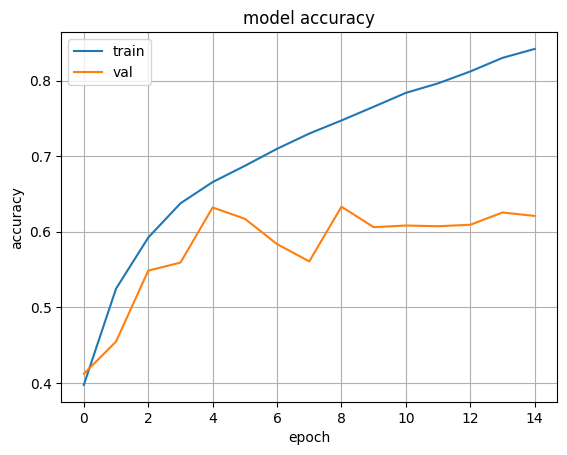

In [98]:
# Validação da acurácia por épocas
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.show()

469/469 [==============================] - 2s 5ms/step


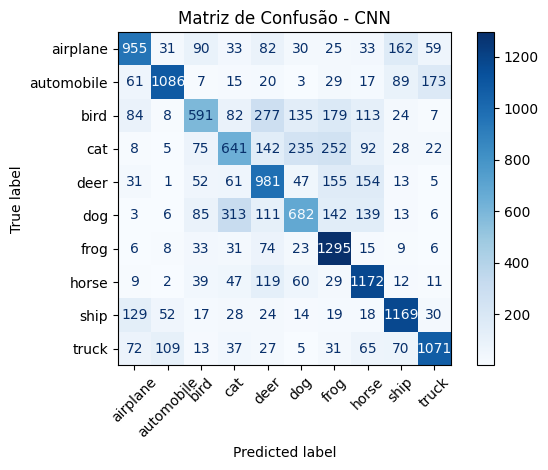

              precision    recall  f1-score   support

    airplane       0.70      0.64      0.67      1500
  automobile       0.83      0.72      0.77      1500
        bird       0.59      0.39      0.47      1500
         cat       0.50      0.43      0.46      1500
        deer       0.53      0.65      0.58      1500
         dog       0.55      0.45      0.50      1500
        frog       0.60      0.86      0.71      1500
       horse       0.64      0.78      0.71      1500
        ship       0.74      0.78      0.76      1500
       truck       0.77      0.71      0.74      1500

    accuracy                           0.64     15000
   macro avg       0.65      0.64      0.64     15000
weighted avg       0.65      0.64      0.64     15000

Accuracy score: 0.6428666666666667


In [101]:
# Armazena as predicações do modelo dos dados de teste
cnn_pred = model.predict(x_test)

cnn_pred = np.argmax(cnn_pred,axis=1)

# Define uma variável para armazenar o rótulo que representa o resultado verdadeiro
y_true = np.argmax(y_test_tf,axis=1)

# Criando a matriz de confusão
cnn_cm = metrics.confusion_matrix(y_true, cnn_pred)

# Visualização
disp = ConfusionMatrixDisplay(
    confusion_matrix=cnn_cm,
    display_labels=category_names
)

disp.plot(cmap="Blues",xticks_rotation=45)

plt.title("Matriz de Confusão - CNN")
plt.tight_layout()
plt.show()

# Definindo a acurácia
cnn_accuracy = metrics.accuracy_score(y_true, cnn_pred)

# Print do classification report
print(metrics.classification_report(y_true, cnn_pred, target_names=category_names))
# Print da acurácia
print("Accuracy score: {}".format(cnn_accuracy))

In [98]:
# -------------- LIBERA MEMORIA

del model
del history

tf.keras.backend.clear_session()
gc.collect()

34805

## Uso de rede pré-treinada como extrator de características e modelo raso como classificador

In [99]:

mob_img_size = 224

#model = ResNet50(include_top=False, weights='imagenet', pooling='avg', input_tensor=Input(shape=(W,H,3)))
model = MobileNetV2(include_top=False, weights='imagenet', pooling='avg', input_tensor=Input(shape=(mob_img_size,mob_img_size,3)))
model.trainable = False

# Lista para armazenar características e classes
X_features = []
y = []

batch_size = 256

# Percorre todas as imagens
for i in range(0, len(x_train), batch_size):

    batch = x_train[i:i+batch_size]

    batch_resize = np.array([
        cv2.resize(img,(mob_img_size,mob_img_size))
        for img in batch
    ])

    batch_resize = preprocess_input(batch_resize)

    features = model.predict(batch_resize, batch_size=batch_size)

    X_features.append(features)

    y.extend(y_train[i:i+batch_size])
    
X = np.vstack(X_features)
y = np.array(y)

# Salva as características extraídas em um csv (um vetor de valores para cada imagem)
df = pd.DataFrame(X)
df.to_csv('X_mob.csv', header=False, index=False)

# Salva y que contém a classe de cada imagem
df_class = pd.DataFrame(y)
df_class.to_csv('y_mob.csv', header=False, index=False)

print("Arquivos salvos com sucesso!")

1/1 [==============================] - 1s 752ms/step
Arquivos salvos com sucesso!


In [100]:
# Labels
y = pd.read_csv('y_mob.csv', header=None)
y=y.to_numpy()
y=np.ravel(y)
print(y.shape)

# deep features
X = pd.read_csv('X_mob.csv', header=None)
X=X.to_numpy()
print(X.shape)
print(y.shape)

(35000,)
(35000, 1280)
(35000,)


In [101]:


# Definição dos parâmetros a serem avaliados
parameters_MLP=[{
    			'hidden_layer_sizes':[(256,), (512,), (512,256)],
             	'activation':['relu', 'logistic'],
             	'alpha':[0.0001,0.001],
             	}
            	]

parameters_SVM = [
  {'C': [1, 5, 10, 50],
   'gamma': [0.1, 0.01, 0.001, 0.0001, 'scale'],
   'kernel': ['rbf', 'poly', 'linear']},
]

# Separar uma parte dos dados para validação
X, X_val, y, y_val=train_test_split(X, y, test_size=0.3, random_state=rand_seed, stratify=y)

# definição da técnica a ser utilizada
clf=MLPClassifier(random_state=rand_seed, max_iter=500, early_stopping=True)
#clf=SVC(probability=True)

gs=GridSearchCV(clf, parameters_MLP, cv=3)
gs.fit(X_val, y_val)

clf=gs.best_estimator_
print("Melhores parâmetros:", gs.best_params_)

c:\Aurelio\Programacao\Pos Grad\.venv10\lib\site-packages\sklearn\model_selection\_search.py:409: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = np.array(param_list)


Melhores parâmetros: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (512,)}


In [102]:
from tabulate import tabulate 

df=gs.cv_results_ 
print(tabulate(df, headers='keys', tablefmt='psql')) 

result=model_selection.cross_val_score(clf, X, y, cv=5) 

print("Accuracy: %.5f" % result.mean()) 
print("std: %.5f" % result.std()) 

y_pred=model_selection.cross_val_predict(clf, X, y, cv=5)

+-----------------+----------------+-------------------+------------------+--------------------+---------------+----------------------------+-------------------------------------------------------------------------------+---------------------+---------------------+---------------------+-------------------+------------------+-------------------+
|   mean_fit_time |   std_fit_time |   mean_score_time |   std_score_time | param_activation   |   param_alpha | param_hidden_layer_sizes   | params                                                                        |   split0_test_score |   split1_test_score |   split2_test_score |   mean_test_score |   std_test_score |   rank_test_score |
|-----------------+----------------+-------------------+------------------+--------------------+---------------+----------------------------+-------------------------------------------------------------------------------+---------------------+---------------------+---------------------+-------------------

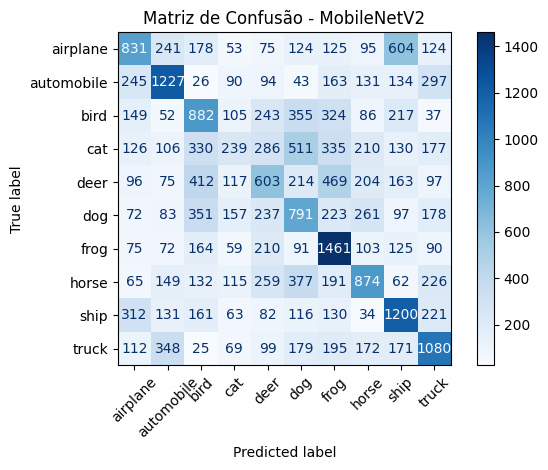

              precision    recall  f1-score   support

    airplane       0.40      0.34      0.37      2450
  automobile       0.49      0.50      0.50      2450
        bird       0.33      0.36      0.35      2450
         cat       0.22      0.10      0.14      2450
        deer       0.28      0.25      0.26      2450
         dog       0.28      0.32      0.30      2450
        frog       0.40      0.60      0.48      2450
       horse       0.40      0.36      0.38      2450
        ship       0.41      0.49      0.45      2450
       truck       0.43      0.44      0.43      2450

    accuracy                           0.38     24500
   macro avg       0.37      0.38      0.36     24500
weighted avg       0.37      0.38      0.36     24500

Accuracy score: 0.3750204081632653


In [103]:

ma=confusion_matrix(y, y_pred)

# Visualizar
disp = ConfusionMatrixDisplay(
        confusion_matrix=ma,
        display_labels=category_names
    )

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusão - MobileNetV2")
plt.tight_layout()
plt.show()

# Criando a matriz de confusão
mobile_cm = metrics.confusion_matrix(y, y_pred)
# Definindo a acurácia
mobile_accuracy = metrics.accuracy_score(y, y_pred)

# Print do classification report
print(metrics.classification_report(y, y_pred, target_names=category_names))
# Print da acurácia
print("Accuracy score: {}".format(mobile_accuracy))

In [104]:
# -------------- LIBERA MEMORIA
tf.keras.backend.clear_session()
gc.collect()

11126

## Criação de batches para utilizar nos proximos modelos (para fine Tuning, Data Augmentation e ViT)

In [28]:
vgg_W = 224
vgg_H = 224

batch_size = 64

X_path = "X_vgg_batches"
os.makedirs(X_path, exist_ok=True)

y_all = []


for i in range(0, len(X_base), batch_size):

    print(f"Processando batch {i}/{len(X_base)}")

    batch = X_base[i:i+batch_size]
    batch_y = y_base[i:i+batch_size]


    batch_resize = np.array([
        cv2.resize(
            img * 255.0,
            (vgg_W, vgg_H)
        )
        for img in batch
    ])


    batch_resize = preprocess_input(batch_resize)


    np.save(
        f"{X_path}/X_batch_{i}.npy",
        batch_resize
    )


    y_all.extend(batch_y)


    del batch_resize
    gc.collect()



np.save(
    "y_vgg.npy",
    np.array(y_all)
)


print("Processamento finalizado!")

Processando batch 0/50000
Processando batch 64/50000
Processando batch 128/50000
Processando batch 192/50000
Processando batch 256/50000
Processando batch 320/50000
Processando batch 384/50000
Processando batch 448/50000
Processando batch 512/50000
Processando batch 576/50000
Processando batch 640/50000
Processando batch 704/50000
Processando batch 768/50000
Processando batch 832/50000
Processando batch 896/50000
Processando batch 960/50000
Processando batch 1024/50000
Processando batch 1088/50000
Processando batch 1152/50000
Processando batch 1216/50000
Processando batch 1280/50000
Processando batch 1344/50000
Processando batch 1408/50000
Processando batch 1472/50000
Processando batch 1536/50000
Processando batch 1600/50000
Processando batch 1664/50000
Processando batch 1728/50000
Processando batch 1792/50000
Processando batch 1856/50000
Processando batch 1920/50000
Processando batch 1984/50000
Processando batch 2048/50000
Processando batch 2112/50000
Processando batch 2176/50000
Proc

In [29]:
# Rótulos
y = np.load("y_vgg.npy")

y = to_categorical(y)

print(y.shape)


# Lista dos arquivos de batch
batch_files = sorted(
    Path("X_vgg_batches").glob("X_batch_*.npy"),
    key=lambda x: int(x.stem.split("_")[-1])
)

(50000, 10)


In [30]:
def dataset_generator(indices):

    indices = set(indices)

    for file in batch_files:

        batch_start = int(file.stem.split("_")[-1])

        X_batch = np.load(
            file,
            mmap_mode="r"
        )

        for i in range(len(X_batch)):

            indice_global = batch_start + i

            if indice_global in indices:

                yield (
                    X_batch[i],
                    y[indice_global]
                )

        del X_batch
        gc.collect()

In [31]:
indices = np.arange(len(y))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.3,
    random_state=rand_seed,
    stratify=np.argmax(y, axis=1)
)

train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.20,
    random_state=rand_seed,
    stratify=np.argmax(y[train_idx], axis=1)
)

In [32]:
train_dataset = tf.data.Dataset.from_generator(
    lambda: dataset_generator(train_idx),
    output_signature=(
        tf.TensorSpec(
            shape=(224,224,3),
            dtype=tf.float32
        ),
        tf.TensorSpec(
            shape=(10,),
            dtype=tf.float32
        )
    )
)

test_dataset = tf.data.Dataset.from_generator(
    lambda: dataset_generator(test_idx),
    output_signature=(
        tf.TensorSpec(
            shape=(224,224,3),
            dtype=tf.float32
        ),
        tf.TensorSpec(
            shape=(10,),
            dtype=tf.float32
        )
    )
)

val_dataset = tf.data.Dataset.from_generator(
    lambda: dataset_generator(val_idx),
    output_signature=(
        tf.TensorSpec(
            shape=(224,224,3),
            dtype=tf.float32
        ),
        tf.TensorSpec(
            shape=(10,),
            dtype=tf.float32
        )
    )
)

In [33]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = (
    train_dataset
    .shuffle(1000)
    .batch(32)
    .prefetch(AUTOTUNE)
)

test_dataset = (
    test_dataset
    .batch(32)
    .prefetch(AUTOTUNE)
)

val_dataset = (
    val_dataset
    .batch(32)
    .prefetch(AUTOTUNE)
)

In [32]:
print(len(batch_files))

782


In [112]:
total = 0

for _, y_batch in test_dataset:
    total += len(y_batch)

print(total)

15000


In [113]:
y_true_dataset = []

for _, y_batch in test_dataset:
    y_true_dataset.extend(
        np.argmax(y_batch.numpy(), axis=1)
    )

y_true_dataset = np.array(y_true_dataset)

print(len(y_true_dataset))
print(len(y[test_idx]))
print(np.mean(y_true_dataset == np.argmax(y[test_idx], axis=1)))

15000
15000
0.099


### 3) Ajuste fino (Fine Tuning) de uma CNN pré-treinada na base de imagens ImageNet.

In [114]:
# Carrega a rede pré-treinada
vgg_conv=VGG16(weights='imagenet', include_top=False, input_shape=(vgg_W, vgg_H, 3))

# Congela inicialmente todas as camadas
vgg_conv.trainable = True

# Congelando as camadas carregadas
for layer in vgg_conv.layers[:-4]:
    layer.trainable = False
   
# Mostrando a topologia da rede carregada
vgg_conv.summary()

# Adaptando a rede para o problema alvo
model = Sequential()
model.add(vgg_conv)
model.add(GlobalAveragePooling2D())
# model.add(GlobalMaxPooling2D())  
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='softmax'))

# Compilando o modelo
model.compile(loss=keras.losses.categorical_crossentropy, 
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
              metrics=['accuracy'])
# Plotando o modelo
model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [115]:
fp='./vgg16_fineT.weights.h5'
mc=tf.keras.callbacks.ModelCheckpoint(
    filepath=fp,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1)

# Monitor para interromper o modelo antecipadamente quando a melhoria da perda de validação for mínima
monitor_fineT = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1, mode='auto')

In [116]:
results_fineT = model.fit(
    train_dataset,
    epochs=training_epochs,
    verbose=1,
    validation_data=val_dataset,
    callbacks=[
        monitor_fineT,
        mc
    ]
)

# carrega os melhores pesos encontrados durante o treinamento
model.load_weights(fp)

Epoch 1/50
    875/Unknown - 164s 174ms/step - loss: 1.3024 - accuracy: 0.5620
Epoch 1: val_accuracy improved from -inf to 0.81400, saving model to .\vgg16_fineT.weights.h5
875/875 [==============================] - 296s 325ms/step - loss: 1.3024 - accuracy: 0.5620 - val_loss: 0.5749 - val_accuracy: 0.8140
Epoch 2/50
875/875 [==============================] - ETA: 0s - loss: 0.6176 - accuracy: 0.7952
Epoch 2: val_accuracy improved from 0.81400 to 0.85543, saving model to .\vgg16_fineT.weights.h5
875/875 [==============================] - 281s 315ms/step - loss: 0.6176 - accuracy: 0.7952 - val_loss: 0.4398 - val_accuracy: 0.8554
Epoch 3/50
875/875 [==============================] - ETA: 0s - loss: 0.4496 - accuracy: 0.8511
Epoch 3: val_accuracy improved from 0.85543 to 0.87686, saving model to .\vgg16_fineT.weights.h5
875/875 [==============================] - 286s 322ms/step - loss: 0.4496 - accuracy: 0.8511 - val_loss: 0.3768 - val_accuracy: 0.8769
Epoch 4/50
875/875 [================

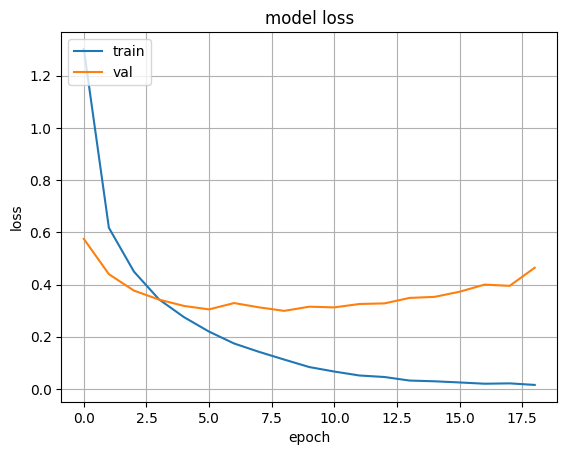

In [117]:
# Validação o erro por épocas
plt.plot(results_fineT.history['loss'])
plt.plot(results_fineT.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.show()

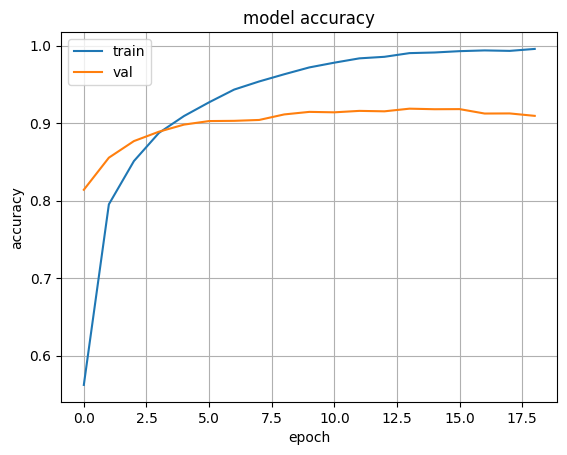

In [118]:
# Validação da acurácia por épocas
plt.plot(results_fineT.history['accuracy'])
plt.plot(results_fineT.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.show()

469/469 [==============================] - 161s 342ms/step


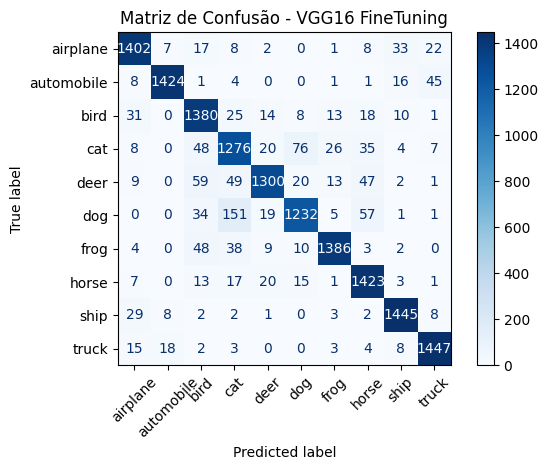

              precision    recall  f1-score   support

    airplane       0.93      0.93      0.93      1500
  automobile       0.98      0.95      0.96      1500
        bird       0.86      0.92      0.89      1500
         cat       0.81      0.85      0.83      1500
        deer       0.94      0.87      0.90      1500
         dog       0.91      0.82      0.86      1500
        frog       0.95      0.92      0.94      1500
       horse       0.89      0.95      0.92      1500
        ship       0.95      0.96      0.96      1500
       truck       0.94      0.96      0.95      1500

    accuracy                           0.91     15000
   macro avg       0.92      0.91      0.91     15000
weighted avg       0.92      0.91      0.91     15000

Accuracy score: 0.9143333333333333


In [119]:
# Predição da VGG16
y_pred_prob = model.predict(test_dataset)

# Classe prevista
y_pred = np.argmax(y_pred_prob, axis=1)

# Classe real
y_true = []

for _, labels in test_dataset:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)

# Matriz de confusão
ma = confusion_matrix(y_true,y_pred)

# Visualização
disp = ConfusionMatrixDisplay(
    confusion_matrix=ma,
    display_labels=category_names
)

disp.plot(cmap="Blues",xticks_rotation=45)

plt.title("Matriz de Confusão - VGG16 FineTuning")
plt.tight_layout()
plt.show()

# Métricas
vgg16_fineT_accuracy = metrics.accuracy_score(y_true, y_pred)

print(metrics.classification_report(y_true,y_pred,target_names=category_names))
print("Accuracy score: {}".format(vgg16_fineT_accuracy))

In [120]:
# -------------- LIBERA MEMORIA
tf.keras.backend.clear_session()
gc.collect()

13267

### 4) CNN FineTuning DataAugmentation

In [125]:
# Utilizando X_base e y_base feitos no anterior

vgg_conv = VGG16(weights='imagenet', include_top=False, input_shape=(vgg_W, vgg_H, 3))

vgg_conv.trainable = True

for layer in vgg_conv.layers[:-4]:
    layer.trainable = False
    
vgg_conv.summary()

# Adaptando a rede para o problema alvo
model = Sequential()
model.add(vgg_conv)
# model.add(Flatten())
model.add(GlobalAveragePooling2D())
#model.add(GlobalMaxPooling2D())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10, activation='softmax'))

# Compilar o modelo
model.compile(loss=keras.losses.categorical_crossentropy, 
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
              metrics=['accuracy'] )

model.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [126]:
# Inicialização do gerador de imagens - aplica aleatoriamente distorções
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.03),
    keras.layers.RandomZoom(0.15),
    keras.layers.RandomTranslation(0.1, 0.1)
])

In [127]:
train_dataset_aug = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset_aug = train_dataset_aug.prefetch(tf.data.AUTOTUNE)

In [128]:
# ModelCheckPoint
fp='./vgg16_dataAug.weights.h5'
mc = tf.keras.callbacks.ModelCheckpoint(

    filepath=fp,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1)

# Monitor para interromper o modelo antecipadamente quando a melhoria da perda de validação for mínima
monitor_dataAug = EarlyStopping(monitor='val_loss', min_delta=1e-5, patience=10, verbose=1, mode='auto')

# Treinamento considerando o gerador de iamgens de treino
history_dataAug = model.fit(train_dataset_aug, 
                            validation_data=val_dataset,
                    		epochs=training_epochs, 
                            verbose=1, 
                            callbacks=[monitor_dataAug, mc]
                            )

# Os pesos do melhor modelo são carregados
model.load_weights(fp)

Epoch 1/50
    875/Unknown - 189s 210ms/step - loss: 1.3628 - accuracy: 0.5361
Epoch 1: val_accuracy improved from -inf to 0.79200, saving model to .\vgg16_dataAug.weights.h5
875/875 [==============================] - 317s 356ms/step - loss: 1.3628 - accuracy: 0.5361 - val_loss: 0.6264 - val_accuracy: 0.7920
Epoch 2/50
875/875 [==============================] - ETA: 0s - loss: 0.6841 - accuracy: 0.7706
Epoch 2: val_accuracy improved from 0.79200 to 0.84657, saving model to .\vgg16_dataAug.weights.h5
875/875 [==============================] - 314s 354ms/step - loss: 0.6841 - accuracy: 0.7706 - val_loss: 0.4658 - val_accuracy: 0.8466
Epoch 3/50
875/875 [==============================] - ETA: 0s - loss: 0.5318 - accuracy: 0.8230
Epoch 3: val_accuracy improved from 0.84657 to 0.87086, saving model to .\vgg16_dataAug.weights.h5
875/875 [==============================] - 296s 333ms/step - loss: 0.5318 - accuracy: 0.8230 - val_loss: 0.3870 - val_accuracy: 0.8709
Epoch 4/50
875/875 [==========

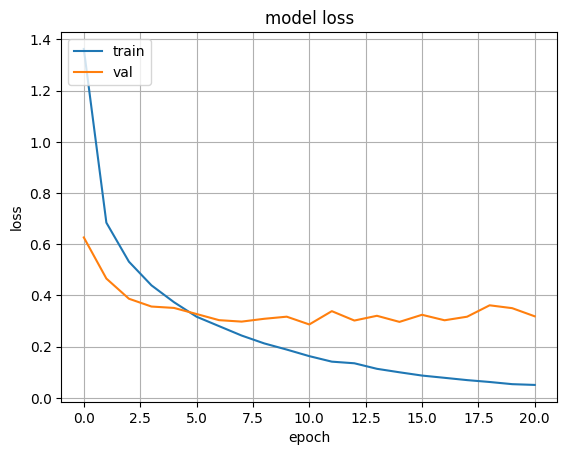

In [129]:
# Validação o erro por épocas
plt.plot(history_dataAug.history['loss'])
plt.plot(history_dataAug.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.show()

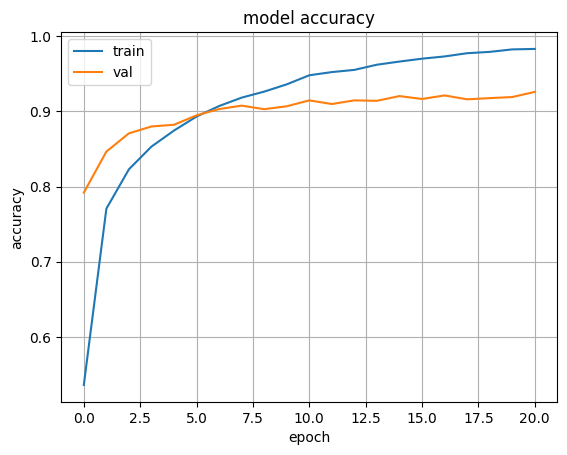

In [130]:
# Validação da acurácia por épocas
plt.plot(history_dataAug.history['accuracy'])
plt.plot(history_dataAug.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.show()

469/469 [==============================] - 108s 230ms/step


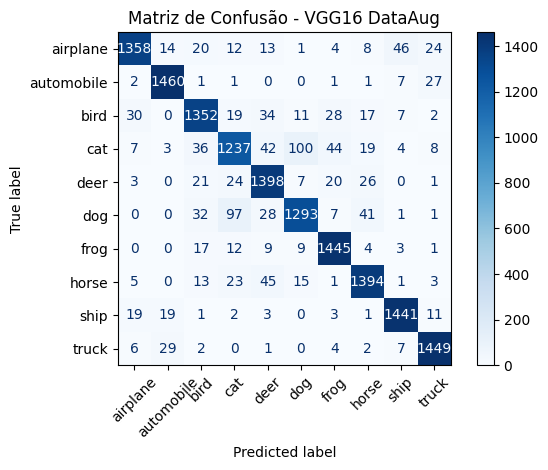

              precision    recall  f1-score   support

    airplane       0.95      0.91      0.93      1500
  automobile       0.96      0.97      0.97      1500
        bird       0.90      0.90      0.90      1500
         cat       0.87      0.82      0.85      1500
        deer       0.89      0.93      0.91      1500
         dog       0.90      0.86      0.88      1500
        frog       0.93      0.96      0.95      1500
       horse       0.92      0.93      0.93      1500
        ship       0.95      0.96      0.96      1500
       truck       0.95      0.97      0.96      1500

    accuracy                           0.92     15000
   macro avg       0.92      0.92      0.92     15000
weighted avg       0.92      0.92      0.92     15000

Accuracy score: 0.9218


In [131]:
# Predição do dataAug
y_pred_prob = model.predict(test_dataset)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = []

for _, labels in test_dataset:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)

# Matriz de confusão
ma = confusion_matrix(y_true,y_pred)

# Visualização
disp = ConfusionMatrixDisplay(
    confusion_matrix=ma,
    display_labels=category_names
)

disp.plot(cmap="Blues",xticks_rotation=45)

plt.title("Matriz de Confusão - VGG16 DataAug")
plt.tight_layout()
plt.show()

# Métricas
vgg16_dataAug_accuracy = metrics.accuracy_score(y_true, y_pred)

print(metrics.classification_report(y_true,y_pred,target_names=category_names))
print("Accuracy score: {}".format(vgg16_dataAug_accuracy))

In [ ]:
# -------------- LIBERA MEMORIA
del model
gc.collect()

tf.keras.backend.clear_session()
gc.collect()

13276

### 5) ajuste fino de um ViT (Visual Transformer)

In [59]:
train_dataset_vit = train_dataset.map(
    lambda x, y: (tf.transpose(x, [0, 3, 1, 2]), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

val_dataset_vit = val_dataset.map(
    lambda x, y: (tf.transpose(x, [0, 3, 1, 2]), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

test_dataset_vit = test_dataset.map(
    lambda x, y: (tf.transpose(x, [0, 3, 1, 2]), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

In [60]:
# ViT oficial do google, da Hugging Face. (mais atual q o tfhub)
vit = TFViTModel.from_pretrained("google/vit-base-patch16-224")
# Congelar inicialmente
vit.trainable = False


c:\Aurelio\Programacao\Pos Grad\.venv10\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFViTModel: ['classifier.bias', 'classifier.weight']
- This IS expected if you are initializing TFViTModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFViTModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFViTModel were not initialized from the PyTorch model and are newly initia

In [61]:
class ViTClassifier(tf.keras.Model):

    def __init__(self, vit, num_classes):
        super().__init__()
        self.vit = vit
        self.dropout = tf.keras.layers.Dropout(0.3)
        self.fc1 = tf.keras.layers.Dense(256, activation="relu")
        self.classifier = tf.keras.layers.Dense(num_classes, activation="softmax")
    def call(self, x, training=False):
        outputs = self.vit(pixel_values=x, training=training)
        # embedding do token CLS
        x = outputs.last_hidden_state[:, 0]
        x = self.dropout(x, training=training)
        x = self.fc1(x)
        return self.classifier(x)

In [62]:
# instanciar modelo
model = ViTClassifier(vit, num_classes)

# Salva os melhores pesos
mc_vit = tf.keras.callbacks.ModelCheckpoint(
    filepath="./vit_best.weights.h5",
    save_weights_only=True,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

# Monitor para interromper o modelo antecipadamente quando a melhoria da perda de validação for mínima
monitor_vit = EarlyStopping(monitor='val_loss', restore_best_weights=True, patience=3, verbose=1, mode='auto')

# Compilar e treinar
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate = 1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [63]:
history_vit = model.fit(
    train_dataset_vit,
    epochs=training_epochs,
    validation_data=val_dataset_vit,
    callbacks=[monitor_vit, mc_vit]
)

model.load_weights("./vit_best.weights.h5")

Epoch 1/50
    875/Unknown - 260s 280ms/step - loss: 2.2102 - accuracy: 0.2013
Epoch 1: val_accuracy improved from -inf to 0.29586, saving model to .\vit_best.weights.h5
875/875 [==============================] - 466s 515ms/step - loss: 2.2102 - accuracy: 0.2013 - val_loss: 1.9483 - val_accuracy: 0.2959
Epoch 2/50
875/875 [==============================] - ETA: 0s - loss: 1.9977 - accuracy: 0.2750
Epoch 2: val_accuracy improved from 0.29586 to 0.33100, saving model to .\vit_best.weights.h5
875/875 [==============================] - 455s 511ms/step - loss: 1.9977 - accuracy: 0.2750 - val_loss: 1.8611 - val_accuracy: 0.3310
Epoch 3/50
875/875 [==============================] - ETA: 0s - loss: 1.9232 - accuracy: 0.3005
Epoch 3: val_accuracy improved from 0.33100 to 0.35371, saving model to .\vit_best.weights.h5
875/875 [==============================] - 453s 509ms/step - loss: 1.9232 - accuracy: 0.3005 - val_loss: 1.8053 - val_accuracy: 0.3537
Epoch 4/50
875/875 [=========================

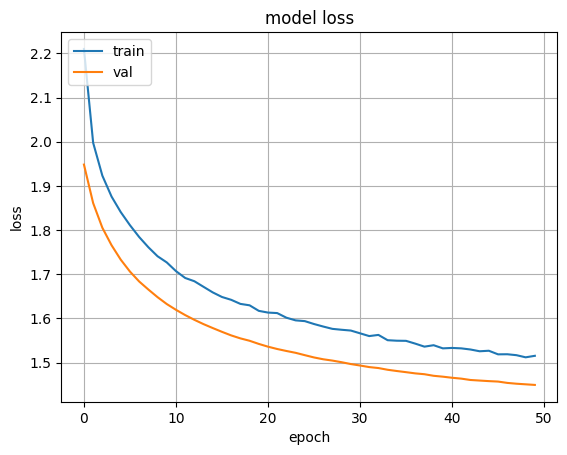

In [64]:
# Validação o erro por épocas
plt.plot(history_vit.history['loss'])
plt.plot(history_vit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.show()

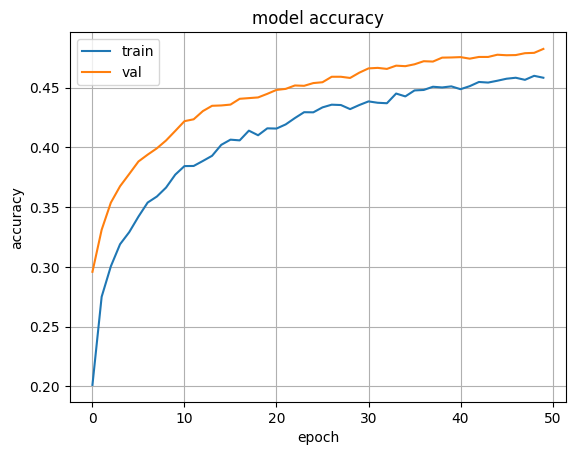

In [65]:
# Validação da acurácia por épocas
plt.plot(history_vit.history['accuracy'])
plt.plot(history_vit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.grid(True)
plt.show()

469/469 [==============================] - 223s 470ms/step


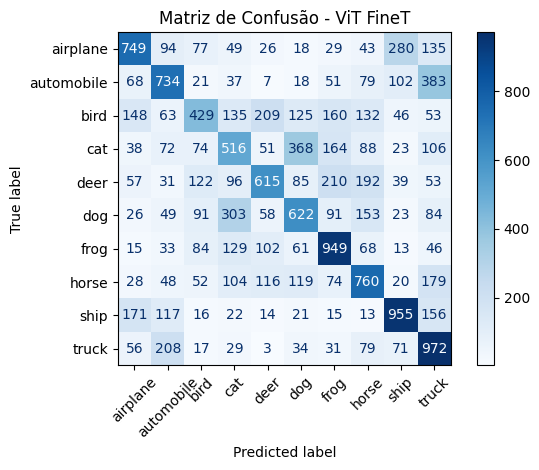

              precision    recall  f1-score   support

    airplane       0.55      0.50      0.52      1500
  automobile       0.51      0.49      0.50      1500
        bird       0.44      0.29      0.35      1500
         cat       0.36      0.34      0.35      1500
        deer       0.51      0.41      0.46      1500
         dog       0.42      0.41      0.42      1500
        frog       0.53      0.63      0.58      1500
       horse       0.47      0.51      0.49      1500
        ship       0.61      0.64      0.62      1500
       truck       0.45      0.65      0.53      1500

    accuracy                           0.49     15000
   macro avg       0.49      0.49      0.48     15000
weighted avg       0.49      0.49      0.48     15000

Accuracy score: 0.48673333333333335


In [66]:
# Predição do VIT
y_pred_prob = model.predict(test_dataset_vit)

y_pred = np.argmax(y_pred_prob, axis=1)

y_true = []

for _, labels in test_dataset_vit:
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)

# Matriz de confusão
ma = confusion_matrix(y_true,y_pred)

# Visualização
disp = ConfusionMatrixDisplay(
    confusion_matrix=ma,
    display_labels=category_names
)

disp.plot(cmap="Blues",xticks_rotation=45)

plt.title("Matriz de Confusão - ViT FineT")
plt.tight_layout()
plt.show()

# Métricas
vit_accuracy = metrics.accuracy_score(y_true, y_pred)

print(metrics.classification_report(y_true,y_pred,target_names=category_names))
print("Accuracy score: {}".format(vit_accuracy))